# 📓 01_flood_event_exploration.ipynb

## Summary

In this notebook, I explored and cleaned the **major flood event dataset for Bhutan**. 

This dataset was 




The main steps included:

- ✅ Loading and inspecting the cleaned xlsx of major flash flood events  
- ✅ Converting date strings to proper `datetime` format  
- ✅ Extracting `year`, `month`, and `day` for temporal analysis  
- ✅ Exploring the distribution of `EventType` and identifying flash floods vs general floods
- ✅ Visualizing flood trends over time (yearly and monthly frequency)  
- ✅ Mapping flood occurrences by district and location   
- ✅ Saving the processed flood dataset to parquet for further analysis (e.g., correlation with ERA5 weather features)

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

### Load the bhutan flood dataset

In [2]:
# Define relative path from the flood_analysis folder
data_path = os.path.join("..", "..", "flood_data", "Bhutan_Historical_Floods_1979_2025.xlsx")

# Load the xlsx
flood_df = pd.read_excel(data_path)

# Preview the first few rows
print("✅ Loaded flood data with shape:", flood_df.shape)
flood_df.head()


✅ Loaded flood data with shape: (113, 11)


,Date,District,Location,Latitude,Longitude,EventType,Description,Rainfall_Time,Gewog,River_Basin,Source
0,1980-07-10,Wangduephodrang,Wangdue town,27.4867,89.8995,Flash Flood,Flash Flood,NaN,NaN,NaN,1
1,1990-08-08,Sarpang,Sarpang,26.8627,90.2717,Flash Flood,Flash Flood,NaN,NaN,NaN,1
2,1994-07-10,Punakha,Punakha,27.5916,89.8774,Flood,Monsoon Flood,NaN,NaN,NaN,1
3,1996-08-14,Phuentsholing,Phuentsholing,26.8635,89.3883,Flood,Major Flood,NaN,NaN,NaN,1
4,2000-07-16,Phuentsholing,Phuentsholing,26.8635,89.3883,Flood,Urban Flooding,NaN,NaN,NaN,1


In [3]:
# Convert Date to datetime
flood_df["Date"] = pd.to_datetime(flood_df["Date"], format="%d/%m/%Y")

# Extract year, month, day for temporal analysis
flood_df["Year"] = flood_df["Date"].dt.year
flood_df["Month"] = flood_df["Date"].dt.month
flood_df["Day"] = flood_df["Date"].dt.day

# Preview
print(flood_df.dtypes)
flood_df.head()

Date             datetime64[ns]
District                 object
Location                 object
Latitude                float64
Longitude               float64
EventType                object
Description              object
Rainfall_Time            object
Gewog                    object
River_Basin              object
Source                    int64
Year                      int32
Month                     int32
Day                       int32
dtype: object


,Date,District,Location,Latitude,Longitude,EventType,Description,Rainfall_Time,Gewog,River_Basin,Source,Year,Month,Day
0,1980-07-10,Wangduephodrang,Wangdue town,27.4867,89.8995,Flash Flood,Flash Flood,NaN,NaN,NaN,1,1980,7,10
1,1990-08-08,Sarpang,Sarpang,26.8627,90.2717,Flash Flood,Flash Flood,NaN,NaN,NaN,1,1990,8,8
2,1994-07-10,Punakha,Punakha,27.5916,89.8774,Flood,Monsoon Flood,NaN,NaN,NaN,1,1994,7,10
3,1996-08-14,Phuentsholing,Phuentsholing,26.8635,89.3883,Flood,Major Flood,NaN,NaN,NaN,1,1996,8,14
4,2000-07-16,Phuentsholing,Phuentsholing,26.8635,89.3883,Flood,Urban Flooding,NaN,NaN,NaN,1,2000,7,16


In [4]:
# Show unique values and their counts
event_type_counts = flood_df["EventType"].value_counts()
print(event_type_counts)

EventType
Flash Flood    66
Flood          47
Name: count, dtype: int64


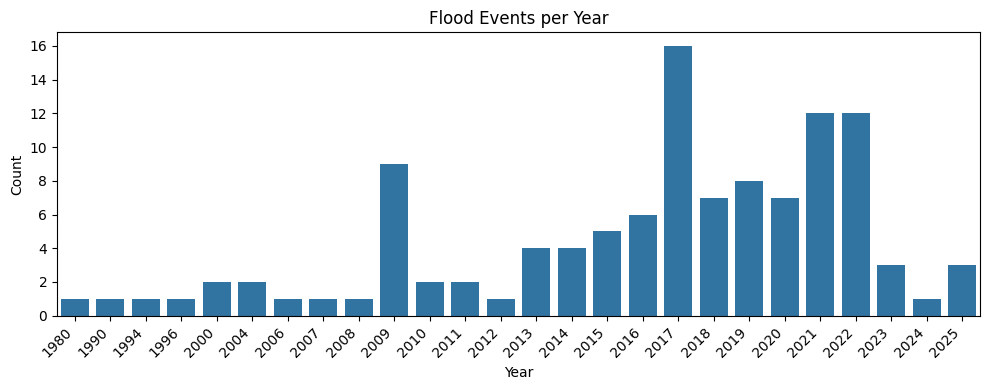

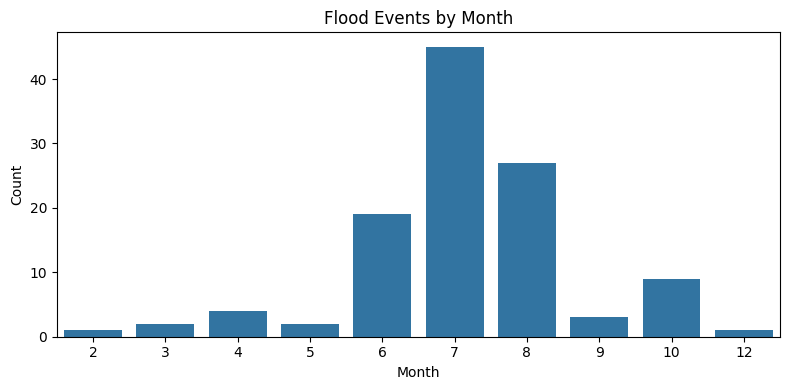

In [5]:
# Events per year
plt.figure(figsize=(10, 4))
sns.countplot(x="Year", data=flood_df)
plt.title("Flood Events per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')  # Rotate and align x-axis labels
plt.tight_layout()
plt.show()

# Events by month (seasonality)
plt.figure(figsize=(8, 4))
sns.countplot(x="Month", data=flood_df)
plt.title("Flood Events by Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


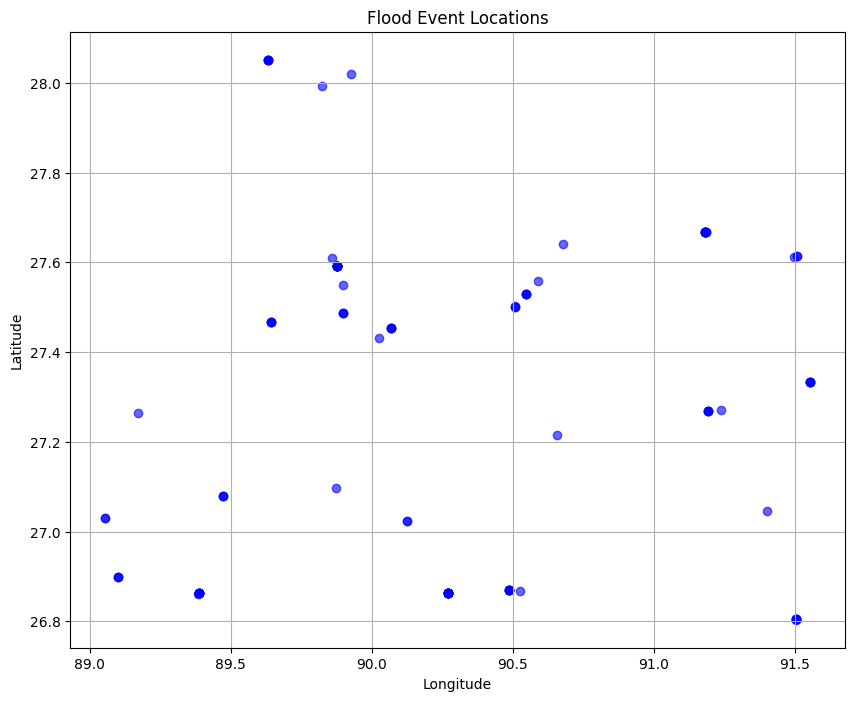

In [6]:
plt.figure(figsize=(10, 8))
plt.scatter(flood_df["Longitude"], flood_df["Latitude"], c='blue', alpha=0.6)
plt.title("Flood Event Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()

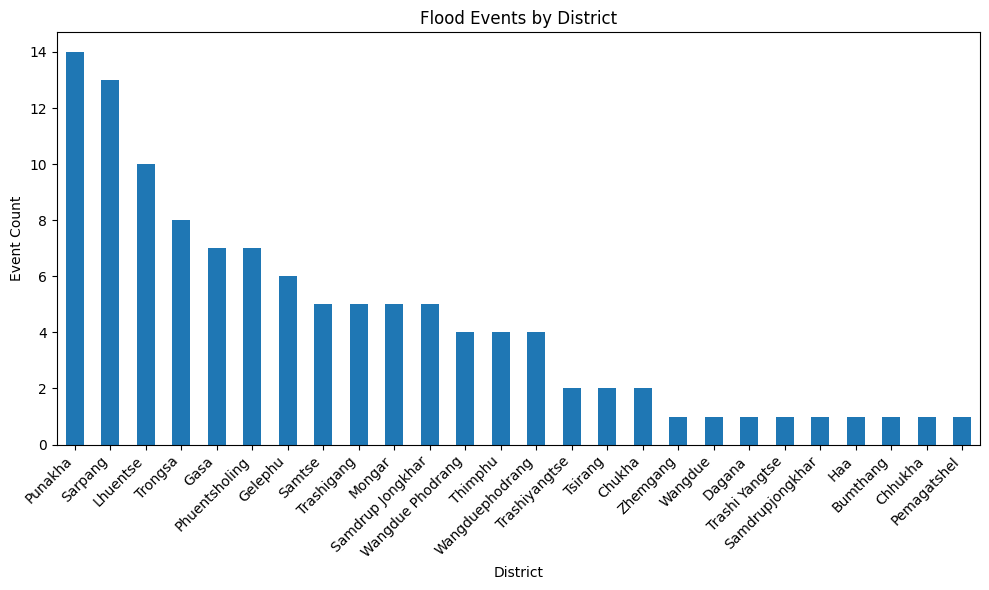

In [7]:
flood_df["District"].value_counts().plot(kind="bar", figsize=(10, 6))
plt.title("Flood Events by District")
plt.ylabel("Event Count")
plt.xlabel("District")
plt.xticks(rotation=45, ha='right')  # rotate and align x-axis labels
plt.tight_layout()
plt.show()

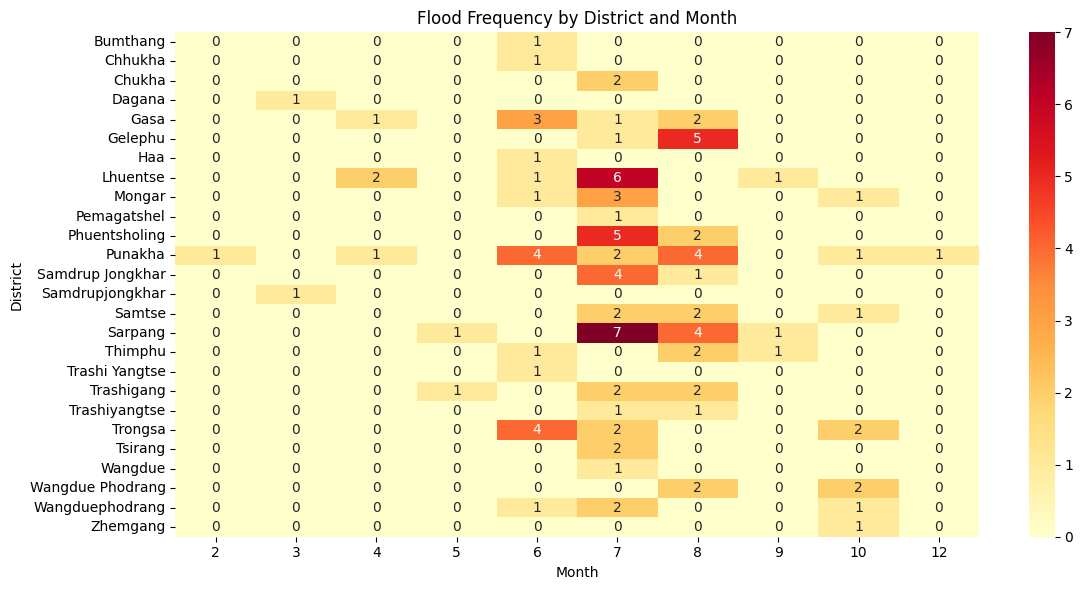

In [8]:
# Group by district and month
flood_df["Month"] = flood_df["Date"].dt.month
heatmap_data = flood_df.groupby(["District", "Month"]).size().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap="YlOrRd", annot=True, fmt="d")
plt.title("Flood Frequency by District and Month")
plt.xlabel("Month")
plt.ylabel("District")
plt.tight_layout()
plt.show()


In [9]:
flood_df.to_parquet("../../flood_data/Bhutan_Historical_Floods_1979_2025_cleaned.parquet", index=False)
